# 1. Environment Setup & Data Ingestion

In this initial phase, we import our primary analytical libraries (`pandas`, `matplotlib`, `seaborn`) and load the raw Fitbit data tracking daily activity and sleep logs.

In [1]:
# 1. Environment Setup & Data Ingestion
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths for both folders
path_march = 'Fitabase Data 3.12.16-4.11.16/dailyActivity_merged.csv'
path_april = 'Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv'
path_sleep = 'Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv'

# Load activity datasets from both date ranges
activity_march = pd.read_csv(path_march)
activity_april = pd.read_csv(path_april)

# Combine both activity datasets into one full dataframe
activity_raw = pd.concat([activity_march, activity_april], ignore_index=True)

# Load sleep dataset
sleep_raw = pd.read_csv(path_sleep)

print(f"Total Raw Activity Records: {len(activity_raw)}")
print(f"Total Raw Sleep Records: {len(sleep_raw)}")

Total Raw Activity Records: 1397
Total Raw Sleep Records: 413


# 2. Data Cleaning, Feature Engineering & Dataset Integration

To ensure data integrity prior to analysis, we perform the following data cleaning procedures:
- Remove duplicate records across both datasets.
- Filter out non-viable records (zero-step activity days).
- Standardize date fields to uniform `datetime` objects.
- **Feature Engineering 1:** Categorize daily steps into standard physical activity tiers (`Sedentary`, `Low Active`, `Somewhat Active`, `Active`).
- **Feature Engineering 2:** Calculate SleepEfficiency as a proxy for sleep quality (TotalMinutesAsleep / TotalTimeInBed * 100).
- Merge activity and sleep datasets on `Id` and `ActivityDate` using an inner join.

In [2]:
# --- Clean Activity Data ---
activity_clean = activity_raw.drop_duplicates().copy()
activity_clean = activity_clean[activity_clean['TotalSteps'] > 0]
activity_clean['ActivityDate'] = pd.to_datetime(activity_clean['ActivityDate'])

# Categorize Activity Tiers
def classify_activity(steps):
    if steps < 5000:
        return 'Sedentary'
    elif steps < 7500:
        return 'Low Active'
    elif steps < 10000:
        return 'Somewhat Active'
    else:
        return 'Active'

activity_clean['ActivityTier'] = activity_clean['TotalSteps'].apply(classify_activity)

# --- Clean Sleep Data ---
sleep_clean = sleep_raw.drop_duplicates().copy()
sleep_clean['SleepDay'] = pd.to_datetime(sleep_clean['SleepDay'], format='mixed')
sleep_clean.rename(columns={'SleepDay': 'ActivityDate'}, inplace=True)

# --- Inner Merge & Feature Engineering ---
merged_df = pd.merge(
    activity_clean,
    sleep_clean,
    on=['Id', 'ActivityDate'],
    how='inner'
)

# Calculate Sleep Efficiency Percentage
merged_df['SleepEfficiency'] = (merged_df['TotalMinutesAsleep'] / merged_df['TotalTimeInBed']) * 100

print(f"Clean Merged Dataset Ready: {len(merged_df)} complete user-days")

Clean Merged Dataset Ready: 421 complete user-days


# 3. Exploratory Data Analysis (EDA)

Here we evaluate the distribution of user activity tiers across our clean dataset and review summary statistics for key health metrics.

In [3]:
# Activity tier distribution percentage
tier_counts = activity_clean['ActivityTier'].value_counts(normalize=True) * 100

print("=== Activity Tier Distribution (%) ===")
print(tier_counts.round(1))

print("\n=== Summary Statistics ===")
display(merged_df[['TotalSteps', 'TotalMinutesAsleep', 'SleepEfficiency']].describe().round(1))

=== Activity Tier Distribution (%) ===
ActivityTier
Active             34.2
Sedentary          28.8
Low Active         20.2
Somewhat Active    16.9
Name: proportion, dtype: float64

=== Summary Statistics ===


,TotalSteps,TotalMinutesAsleep,SleepEfficiency
count,421.0,421.0,421.0
mean,8328.9,419.9,91.6
std,4267.8,118.8,8.8
min,8.0,58.0,49.8
25%,4993.0,361.0,91.2
50%,8758.0,433.0,94.3
75%,11193.0,492.0,96.1
max,22770.0,796.0,100.0


## 4. Data Visualization & Strategic Insights

To evaluate the cross-variable relationship between daytime movement and night-time recovery, we construct a custom scatter plot with an integrated trendline mapping:

* **X-Axis (Continuous):** Total Daily Steps across all recorded user days.
* **Y-Axis (Continuous):** Sleep Efficiency (%) calculated as (TotalMinutesAsleep / TotalTimeInBed * 100)
* **Categorical Encoding (Hue):** Activity Tiers (*Sedentary, Low Active, Somewhat Active, Active*) to contextualize step volumes across user segments.
* **Regression Overlay:** A linear trendline highlighting the macro-level relationship between activity volume and sleep quality.

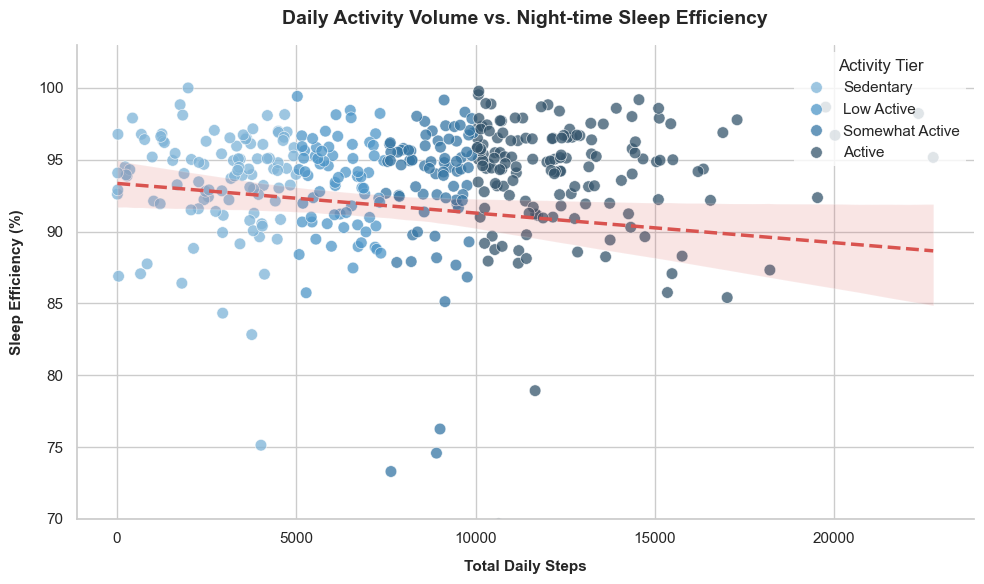

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean overall aesthetic
sns.set_theme(style="whitegrid", font="sans-serif")
fig, ax = plt.subplots(figsize=(10, 6))

tier_order = ['Sedentary', 'Low Active', 'Somewhat Active', 'Active']

# 1. Scatter Plot mapping steps vs. sleep efficiency
scatter = sns.scatterplot(
    data=merged_df,
    x='TotalSteps',
    y='SleepEfficiency',
    hue='ActivityTier',
    hue_order=tier_order,
    palette='Blues_d',
    alpha=0.75,
    s=70,
    edgecolor='w',
    linewidth=0.5,
    ax=ax
)

# 2. Linear Regression Line to illustrate macro direction
sns.regplot(
    data=merged_df,
    x='TotalSteps',
    y='SleepEfficiency',
    scatter=False,
    color='#d9534f',
    line_kws={'linestyle': '--', 'linewidth': 2.5, 'label': 'Overall Trend'},
    ax=ax
)

# Formatting axes & labels
ax.set_title('Daily Activity Volume vs. Night-time Sleep Efficiency', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Daily Steps', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Sleep Efficiency (%)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylim(70, 103)  # Leave headroom for legend and annotations

# Clean legend placement
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title='Activity Tier', frameon=True, facecolor='white', edgecolor='none', loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

## 5. Strategic Recommendations for Bellabeat

Based on the empirical findings from the activity and sleep analysis, we recommend three targeted strategies for the Bellabeat product ecosystem:

* **Smart Recovery Reminders:** Introduce automated app prompts for high-activity days (e.g., users surpassing 10,000 steps) encouraging wind-down routines, hydration, or light stretching to prevent sleep efficiency drops.
* **Holistic Health Positioning:** Shift marketing messaging from solely focusing on daily step goals toward balancing physical activity with adequate sleep hygiene and recovery.
* **Contextual Notifications:** Utilize predictive sleep metrics to send dynamic bedtime reminders based on the user's daily energy expenditure.

## 6. Project Limitations & Future Directions

While these insights offer a strong baseline for product positioning, a few key data limitations should be considered:

* **Sample Size & Scope:** The analyzed Fitbit dataset tracks a relatively small user cohort over a short timeframe. Expanding to a larger, long-term dataset would better capture seasonal habits and individual behavior changes over time.
* **Demographic Context:** The dataset lacks demographic details—such as user age, baseline fitness levels, or lifestyle markers—which restricts deeper audience segmentation and persona building.
* **Data Integrity & Wear Time:** Instances of unrecorded sleep logs or non-wear days create data gaps. Future analyses would benefit from real-time wear-detection metadata to separate true sedentary behavior from unmonitored time.